# SC/ST Targeting in MGNREGA and Political Competition
## District × Year Panel(effectively Pooled) Analysis

**Research question:** Does political competition affect the equity of MGNREGA targeting towards Scheduled Castes and Scheduled Tribes?

**Outcome variable:** SC/ST targeting ratio = (SC or ST share of MGNREGA person-days) / (SC or ST population share). A ratio > 1 means a group receives more than its population-proportionate share of programme benefits; < 1 means under-representation.

**Empirical design:** OLS panel with district and year fixed effects. Political competition is measured using Kjelsrud et al.'s (2024) pre-delimitation fragmentation index averaged to the district level. Note: because the outcome is only available at district level, we cannot replicate the within-pre-delim-PC identification strategy from Kjelsrud — this is a within-district-over-time comparison, not a quasi-experiment.

**Data sources:**
- `nrega.dta` — Kjelsrud replication package; GP × year; political competition variables
- `6026_source_data.csv` — NDAP; district × year; SC/ST MGNREGA person-days 2011–2014
- `pc11_vd_clean_pc11dist.csv` — SHRUG Census 2011 rural; district-level SC/ST and total population
- SHRUG key files — crosswalk from numeric `district2011` codes to district names for NDAP matching

## Setup: Imports and Paths

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels.panel import PanelOLS

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

BASE = "/Users/vidhi/VSCODE/Econ_191_paper/FinalPaperMaterial copy/2. Data/1. Raw"

PATHS = {
    "nrega"        : f"{BASE}/Kjelsrud/ReplicationPackage/Datafiles/nrega.dta",
    "ndap"         : f"{BASE}/NDAP District level MGNREGA/6026/6026_source_data.csv",
    "shrug_keys"   : f"{BASE}/SHRUG/shrug-pc-keys-csv/pc11r_shrid_key.csv",
    "shrug_loc"    : f"{BASE}/SHRUG/shrug-shrid-keys-csv/shrid_loc_names.csv",
    "shrug_census" : f"{BASE}/SHRUG/2011 population census rural/pc11_vd_clean_pc11dist.csv",
}

# The 14 states covered by Kjelsrud (Census 2011 state codes)
KJELSRUD_STATES = [3, 6, 9, 10, 19, 21, 22, 23, 24, 27, 28, 29, 32, 33]

# Same states as they appear in NDAP (uppercase)
KJELSRUD_STATES_NDAP = [
    'PUNJAB', 'HARYANA', 'UTTAR PRADESH', 'BIHAR', 'WEST BENGAL',
    'ODISHA', 'CHHATTISGARH', 'MADHYA PRADESH', 'GUJARAT',
    'MAHARASHTRA', 'ANDHRA PRADESH', 'KARNATAKA', 'KERALA', 'TAMIL NADU'
]

## Step 1: Build District Name Crosswalk

`district2011` in Kjelsrud's `nrega.dta` is the Census 2011 national sequential district code (1–640), which is the same as `pc11_district_id` in SHRUG. SHRUG's location names file maps each `shrid2` (village identifier) to human-readable state and district names. We merge the two SHRUG files to get one row per district code with its name, which we will later use to match against NDAP's text-based district names.

In [52]:
shrug_keys = pd.read_csv(PATHS["shrug_keys"])
shrug_loc  = pd.read_csv(PATHS["shrug_loc"])

print("SHRUG keys description:")
display(shrug_keys.describe())
print("SHRUG location description:")
display(shrug_loc.describe())

SHRUG keys description:


,pc11_state_id,pc11_district_id,pc11_subdistrict_id,pc11_village_id,pc11_land_area,pc11_pca_tot_p
count,597597.000000,597597.000000,597596.000000,597597.000000,597588.000000,597597.000000
mean,16.863155,314.792007,2396.505902,323579.797524,4.387959,1394.979478
std,8.475870,166.870548,1633.099950,186524.994891,11.982922,1960.411910
min,1.000000,1.000000,1.000000,1.000000,0.001090,1.000000
25%,9.000000,175.000000,889.000000,161304.000000,1.063007,369.000000
50%,19.000000,338.000000,2340.000000,324388.000000,2.329850,832.000000
75%,23.000000,447.000000,3600.000000,485639.000000,4.913700,1694.000000
max,35.000000,640.000000,5924.000000,645608.000000,3731.870000,66062.000000


SHRUG location description:


,shrid2,state_name,district_name,subdistrict_name,town_name,village_name,place_name
count,596389,596389,596389,596239,7669,588719,596388
unique,596389,35,625,5616,7248,395790,400112
top,11-01-001-00001-000001,uttar pradesh,paschim medinipur,lalganj,ramgarh,rampur,rampur
freq,1,98652,7535,1773,7,767,770


In [53]:
# Merge keys → loc to attach state_name and district_name to each district code.
# Each shrid2 is a village; drop_duplicates keeps one name per (state_id, district_id) pair.
crosswalk = (
    shrug_keys[['shrid2', 'pc11_state_id', 'pc11_district_id']]
    .merge(shrug_loc[['shrid2', 'state_name', 'district_name']], on='shrid2')
    .drop_duplicates(subset=['pc11_state_id', 'pc11_district_id'])
    [['pc11_state_id', 'pc11_district_id', 'state_name', 'district_name']]
    .rename(columns={'pc11_state_id': 'state', 'pc11_district_id': 'district2011'})
)

# Keep only the 14 Kjelsrud states
crosswalk = crosswalk[crosswalk['state'].isin(KJELSRUD_STATES)].copy()

print(f"Crosswalk: {len(crosswalk)} districts across {crosswalk['state'].nunique()} states")
crosswalk.head()

Crosswalk: 422 districts across 14 states


,state,district2011,state_name,district_name
24219,3,35,punjab,gurdaspur
25734,3,36,punjab,kapurthala
26346,3,37,punjab,jalandhar
27268,3,38,punjab,hoshiarpur
28653,3,39,punjab,shahid bhagat singh nagar


## Step 2: SC/ST Population Shares from SHRUG Census 2011

The targeting ratio requires a denominator: the SC/ST population share in each district. We use the SHRUG district-level aggregation of Census 2011 rural village data (`pc11_vd_clean_pc11dist.csv`), which provides total population (`pc11_vd_t_p`), SC population (`pc11_vd_sc_p`), and ST population (`pc11_vd_st_p`) per district. These are rural population counts only, consistent with MGNREGA's rural focus.

Note this is rural-only Census data. MGNREGA is a rural programme so this is appropriate, but bear in mind a small share of districts' SC/ST population lives in urban areas and is excluded from this denominator.

In [54]:
census = pd.read_csv(PATHS["shrug_census"])

census.columns

Index(['pc11_state_id', 'pc11_district_id', 'pc11_vd_t_hh', 'pc11_vd_t_p',
       'pc11_vd_t_m', 'pc11_vd_t_f', 'pc11_vd_sc_p', 'pc11_vd_sc_m',
       'pc11_vd_sc_f', 'pc11_vd_st_p',
       ...
       'pc11_vd_land_oth_src_irr', 'pc11_vd_subdistrict_hq_dist',
       'pc11_vd_district_hq_dist', 'pc11_vd_town_dist', 'pc11_vd_s_town_dist',
       'pc11_vd_wi_st_town_dist', 'pc11_vd_out_st_town_dist',
       'pc11_vd_atm_dist', 'land_flag', 'dist_flag'],
      dtype='str', length=281)

In [55]:
census = (
    census[census['pc11_state_id'].isin(KJELSRUD_STATES)]
    [['pc11_state_id', 'pc11_district_id', 'pc11_vd_t_p', 'pc11_vd_sc_p', 'pc11_vd_st_p']]
    .rename(columns={
        'pc11_state_id'    : 'state',
        'pc11_district_id' : 'district2011',
        'pc11_vd_t_p'      : 'total_pop',
        'pc11_vd_sc_p'     : 'sc_pop',
        'pc11_vd_st_p'     : 'st_pop',
    })
    .copy()
)

census['sc_pop_share'] = census['sc_pop'] / census['total_pop']
census['st_pop_share'] = census['st_pop'] / census['total_pop']

print(f"Census: {len(census)} districts")
print(census[['sc_pop_share', 'st_pop_share']].describe().round(3))

Census: 422 districts
       sc_pop_share  st_pop_share
count       422.000       422.000
mean          0.189         0.123
std           0.092         0.204
min           0.001         0.000
25%           0.127         0.001
50%           0.192         0.026
75%           0.241         0.146
max           0.534         0.983


## Step 3: Collapse nrega.dta to District × Year

`nrega.dta` is a GP × year panel (150,413 GPs × 3 years). We aggregate to the district × year level by taking the unweighted mean of political competition variables across GPs within each district-year cell. This gives us one observation per district per year, with district-average measures of fragmentation, electoral margin, and the share of GPs that were redistricted.

**Variables kept:**
- `fragmentation` — Herfindahl-based fragmentation index from the 2004 election in the GP's post-delimitation PC (higher = more competitive)
- `min_margin` — 1 minus the winner's margin of victory (higher = more competitive)
- `eff_parties` — effective number of parties
- `share_change_pc` — share of GPs in the district that were redistricted (potential instrument)
- Controls: population, urbanisation, share of children under 6, literacy, poverty

In [56]:
nrega = pd.read_stata(PATHS["nrega"])
nrega.describe()

,state,district2011,gp_id,year,pc_id_pre,pc_id_post,change_pc,matched_pc_post,postbank,sPostbank,...,share_lit_past,religion_frac_past,caste_frac_past,share_blocksplit,distance_km,change_ac,split_block,poverty_pre66_past,pc_dist_y,mean_share_acW
count,451231.000000,451231.000000,451231.000000,451231.000000,451231.000000,451231.000000,451231.000000,451231.000000,4.512310e+05,4.512310e+05,...,451231.000000,451231.000000,451231.000000,451231.000000,388423.000000,451231.000000,451231.000000,451231.000000,451231.000000,451231.000000
mean,18.870060,359.045828,75874.242188,2011.999878,275.616821,568.212524,0.269215,570.748474,7.755589e+05,8.656874e-09,...,0.528728,0.782109,0.389474,0.298873,8.646873,0.291132,0.290913,0.337150,1858.613770,0.291024
std,9.032354,176.693525,43747.273438,0.816497,131.869354,152.951080,0.443552,150.328201,1.734302e+06,1.000000e+00,...,0.102678,0.338428,0.111589,0.235848,7.541114,0.454285,0.454184,0.177975,987.426758,0.195925
min,3.000000,35.000000,1.000000,2011.000000,1.000000,1.000000,0.000000,1.000000,0.000000e+00,-4.471879e-01,...,0.238727,0.001267,0.069023,0.000000,0.000122,0.000000,0.000000,0.003171,1.000000,0.000000
25%,9.000000,182.000000,38016.000000,2011.000000,205.000000,461.000000,0.000000,467.000000,3.901000e+04,-4.246947e-01,...,0.460987,0.511740,0.310278,0.111260,2.749825,0.000000,0.000000,0.186628,1305.000000,0.167403
50%,23.000000,420.000000,75937.000000,2012.000000,268.000000,559.000000,0.000000,562.000000,2.958930e+05,-2.765758e-01,...,0.540309,1.000000,0.388098,0.268438,6.884953,0.000000,0.000000,0.338888,1758.000000,0.267343
75%,27.000000,506.000000,113726.000000,2013.000000,406.000000,698.000000,1.000000,695.000000,8.167960e+05,2.377739e-02,...,0.601697,1.000000,0.475211,0.439780,12.120678,1.000000,1.000000,0.471025,2734.000000,0.373547
max,33.000000,633.000000,151660.000000,2013.000000,524.000000,820.000000,1.000000,820.000000,1.202010e+08,6.886084e+01,...,0.856659,1.000000,0.649293,1.000000,45.653965,1.000000,1.000000,0.825057,3780.000000,1.000000


In [57]:
# Cast to int
nrega['state']        = nrega['state'].astype(int)
nrega['district2011'] = nrega['district2011'].astype(int)
nrega['year']         = nrega['year'].astype(int)

nrega_district = (
    nrega
    .groupby(['state', 'district2011', 'year'])
    .agg(
        fragmentation   = ('fragmentation_2004_past',   'mean'),
        min_margin      = ('min_margin_2004_past',       'mean'),
        eff_parties     = ('effective_parties_2004_past','mean'),
        share_change_pc = ('change_pc',                  'mean'),
        n_gps           = ('gp_id',                      'nunique'),
        population      = ('population_past',             'mean'),
        urbanization    = ('urbanization_past',           'mean'),
        share_l6        = ('share_l6_past',               'mean'),
        share_lit       = ('share_lit_past',              'mean'),
        poverty         = ('poverty_pre66_past',          'mean'),
        caste_frac      = ('caste_frac_past',             'mean'),
        religion_frac   = ('religion_frac_past',          'mean'),
    )
    .reset_index()
)

print(f"nrega_district: {len(nrega_district)} rows | "
      f"{nrega_district['district2011'].nunique()} districts × "
      f"{nrega_district['year'].nunique()} years")
nrega_district.head()

nrega_district: 1236 rows | 412 districts × 3 years


,state,district2011,year,fragmentation,min_margin,eff_parties,share_change_pc,n_gps,population,urbanization,share_l6,share_lit,poverty,caste_frac,religion_frac
0,3,35,2011,0.555118,0.966755,2.264364,0.107835,1187,1875629.375,0.226610,0.135606,0.657565,0.186840,0.387538,0.834246
1,3,35,2012,0.555138,0.966752,2.264492,0.108017,1185,1875602.625,0.226614,0.135603,0.657569,0.186828,0.387559,0.834214
2,3,35,2013,0.555138,0.966752,2.264492,0.108017,1185,1875602.625,0.226614,0.135603,0.657569,0.186828,0.387559,0.834214
3,3,36,2011,0.597274,0.935692,2.520089,0.600451,443,1526536.500,0.177820,0.136490,0.591300,0.202278,0.467071,0.844506
4,3,36,2012,0.597274,0.935692,2.520089,0.600451,443,1526536.500,0.177820,0.136490,0.591300,0.202278,0.467071,0.844506


## Step 4: Prepare NDAP SC/ST MGNREGA Data

The NDAP dataset (`6026_source_data.csv`) contains district × financial-year records for all Indian states. We:
1. Filter to the 14 Kjelsrud states and the three financial years that overlap with Kjelsrud's panel (2011-12, 2012-13, 2013-14)
2. Map financial year labels to integers matching Kjelsrud's `year` variable (2011, 2012, 2013)
3. Compute the SC and ST shares of total MGNREGA person-days — these are the numerators of the targeting ratios
4. Standardise state and district name strings to lowercase for matching with the SHRUG crosswalk

In [67]:
ndap = pd.read_csv(PATHS["ndap"])
ndap.columns

Index(['srcYear', 'srcStateName', 'srcDistrictName',
       'Households that applied for a Job Card', 'Job Cards issued',
       'Job Cards issued for Scheduled Caste',
       'Job Cards issued for Scheduled Tribes',
       'Job Cards issued for non Scheduled Tribes or Scheduled Caste',
       'Households that demanded work', 'Persons who demanded work',
       'Households that were allotted work', 'Persons that were allotted work',
       'Muster Rolls filled',
       'Households that worked under Mahatma Gandhi National Rural Employment Guarantee Act (MGNREGA)',
       'Persons that worked under Mahatma Gandhi National Rural Employment Guarantee Act (MGNREGA)',
       'Households that reached a 100 day limit', 'Persons with disability',
       'Non Scheduled Tribes or Scheduled Caste households that worked',
       'Total Person days worked by non Scheduled Tribes or Scheduled Caste persons',
       'Scheduled Caste households that worked',
       'Total Person days worked Scheduled 

In [68]:
ndap = pd.read_csv(PATHS["ndap"])

ndap = ndap[
    ndap['srcYear'].isin(['2011-12', '2012-13', '2013-14']) &
    ndap['srcStateName'].isin(KJELSRUD_STATES_NDAP)
].copy()

ndap['year'] = ndap['srcYear'].map({'2011-12': 2011, '2012-13': 2012, '2013-14': 2013})

ndap['state_name']    = ndap['srcStateName'].str.lower().str.strip()
ndap['district_name'] = ndap['srcDistrictName'].str.lower().str.strip()

sc_pd = ndap['Total Person days worked Scheduled Caste persons']
st_pd = ndap['Total Person days worked Scheduled Tribe persons']
tot   = ndap['Total Person days']

ndap['sc_pd_share']   = sc_pd / tot
ndap['st_pd_share']   = st_pd / tot
ndap['scst_pd_share'] = (sc_pd + st_pd) / tot   # combined SC+ST share

ndap_clean = ndap[[
    'state_name', 'district_name', 'year',
    'sc_pd_share', 'st_pd_share', 'scst_pd_share',
    'Total Person days',
    'Households that demanded work',
    'Amount sanctioned',
    'Works under Mahatma Gandhi National Rural Employment Guarantee Act (MGNREGA)',
]].rename(columns={
    'Households that demanded work'                                                : 'hh_demanded',
    'Amount sanctioned'                                                            : 'amount_sanctioned',
    'Works under Mahatma Gandhi National Rural Employment Guarantee Act (MGNREGA)': 'total_works',
}).copy()

print(f"NDAP: {len(ndap_clean)} district-years | {ndap_clean['district_name'].nunique()} districts")
print(ndap_clean[['sc_pd_share', 'st_pd_share', 'scst_pd_share']].describe().round(3))


NDAP: 1296 district-years | 431 districts
       sc_pd_share  st_pd_share  scst_pd_share
count     1235.000     1235.000       1235.000
mean         0.256        0.136          0.392
std          0.187        0.215          0.217
min          0.001        0.000          0.008
25%          0.124        0.002          0.238
50%          0.219        0.026          0.348
75%          0.339        0.187          0.505
max          0.945        0.985          0.985


## Step 5: Merge All Datasets

We build the final panel in two stages:

**Stage A — Numeric keys (exact):** Attach the SHRUG district names and the Census population shares to `nrega_district` using the numeric `(state, district2011)` key. These joins are exact because all three files share the same Census 2011 coding.

**Stage B — Name-based (mostly exact, some manual fixes):** Merge the result from Stage A with the NDAP data using the `(state_name, district_name, year)` string key. SHRUG and NDAP use slightly different romanisations for a small number of districts (e.g. `kancheepuram` vs `kanchipuram`). We apply a manual correction dictionary for known mismatches, then report how many district-years were matched.

In [69]:
# ── Stage A: Attach SHRUG district names and Census population shares ─────────
panel = (
    nrega_district
    .merge(crosswalk, on=['state', 'district2011'], how='left')
    .merge(census[['state', 'district2011', 'sc_pop_share', 'st_pop_share',
                   'total_pop', 'sc_pop', 'st_pop']],
           on=['state', 'district2011'], how='left')
)

# Normalise name strings for NDAP matching
panel['state_name_clean']    = panel['state_name'].str.lower().str.strip()
panel['district_name_clean'] = panel['district_name'].str.lower().str.strip()

# ── Stage B: Merge NDAP by name ───────────────────────────────────────────────

# Known SHRUG → NDAP name corrections (add more here if the unmatched check below reveals them)
NAME_FIXES = {
    'kancheepuram' : 'kanchipuram',
    'allahabad'    : 'prayagraj',      # renamed 2018 — NDAP may use old or new name
}
panel['district_name_for_merge'] = panel['district_name_clean'].replace(NAME_FIXES)

panel = panel.merge(
    ndap_clean,
    left_on  = ['state_name_clean', 'district_name_for_merge', 'year'],
    right_on = ['state_name',       'district_name',           'year'],
    how='left'
)

# ── Coverage report ───────────────────────────────────────────────────────────
n_total   = len(panel)
n_matched = panel['sc_pd_share'].notna().sum()
print(f"Matched: {n_matched} / {n_total} district-years  ({100*n_matched/n_total:.1f}%)")

unmatched = (
    panel[panel['sc_pd_share'].isna()]
    [['state_name_clean', 'district_name_clean']]
    .drop_duplicates()
    .sort_values(['state_name_clean', 'district_name_clean'])
)
print(f"\nUnmatched districts ({len(unmatched)}):")
print(unmatched.to_string(index=False))

Matched: 979 / 1236 district-years  (79.2%)

Unmatched districts (106):
state_name_clean         district_name_clean
  andhra pradesh sri potti sriramulu nellore
  andhra pradesh               visakhapatnam
  andhra pradesh                  ysr kadapa
           bihar                      araria
           bihar                       arwal
           bihar                  aurangabad
           bihar                       banka
           bihar                   begusarai
           bihar                   bhagalpur
           bihar                     bhojpur
           bihar                       buxar
           bihar                   darbhanga
           bihar                   gopalganj
           bihar                       jamui
           bihar                   jehanabad
           bihar                     katihar
           bihar                    khagaria
           bihar                  kishanganj
           bihar                  lakhisarai
           bihar            

In [70]:
# ── Additional name fixes based on the unmatched list ────────────────────────
#
# Three names conflict across states and CANNOT be fixed with a global rename:
#   'aurangabad'  — Bihar needs → 'auranagabad', but Maharashtra already matches 'aurangabad'
#   'bijapur'     — Karnataka needs → 'vijaypura',  but Chhattisgarh already matches 'bijapur'
#   'raigarh'     — Maharashtra needs → 'raigad',   but Chhattisgarh already matches 'raigarh'
# These three are left unmatched; fixing them requires state-aware logic (see below).
#
# Bihar note: ALL Bihar districts are unmatched despite exact name overlap.
# This likely means Bihar's MGNREGA data is absent from NDAP for 2011-13
# (known reporting gaps in early years). Name fixes added anyway for completeness.

EXTRA_FIXES = {
    # ── Andhra Pradesh ────────────────────────────────────────────────────────
    'sri potti sriramulu nellore' : 'nellore',
    'visakhapatnam'               : 'visakhapatanam',
    'ysr kadapa'                  : 'cuddapah',
    # ── Bihar (name fixes; data may still be missing from NDAP for 2011-13) ──
    'purba champaran'             : 'purbi champaran',
    # ── Chhattisgarh ─────────────────────────────────────────────────────────
    'dakshin bastar dantewada'    : 'dantewada',
    'janjgir champa'              : 'janjgir-champa',
    'kabeerdham'                  : 'kawardha',
    'koriya'                      : 'korea',
    'rajnandgaon'                 : 'rajnandagon',
    'uttar bastar kanker'         : 'kanker',
    # ── Gujarat ──────────────────────────────────────────────────────────────
    'the dangs'                   : 'dang',
    # ── Haryana ──────────────────────────────────────────────────────────────
    'gurgaon'                     : 'gurugram',
    # ── Karnataka (excluding 'bijapur' — conflicts with Chhattisgarh) ────────
    'bagalkot'                    : 'bagalkote',
    'bangalore'                   : 'bengaluru',
    'bangalore rural'             : 'bengaluru rural',
    'belgaum'                     : 'belagavi',
    'bellary'                     : 'ballari',
    'chamarajanagar'              : 'chamaraja nagara',
    'chikmagalur'                 : 'chikkamagaluru',
    'dharwad'                     : 'dharwar',
    'gulbarga'                    : 'kalaburagi',
    'mysore'                      : 'mysuru',
    'shimoga'                     : 'shivamogga',
    'tumkur'                      : 'tumakuru',
    # ── Kerala ───────────────────────────────────────────────────────────────
    'kasaragod'                   : 'kasargod',
    # ── Madhya Pradesh ───────────────────────────────────────────────────────
    'ashoknagar'                  : 'ashok nagar',
    'east nimar'                  : 'khandwa',
    'narsimhapur'                 : 'narsinghpur',
    'west nimar'                  : 'khargone',
    # ── Maharashtra (excluding 'raigarh' — conflicts with Chhattisgarh) ──────
    'ahmadnagar'                  : 'ahmednagar',
    'bid'                         : 'beed',
    'buldana'                     : 'buldhana',
    'gondiya'                     : 'gondia',
    # ── Odisha ───────────────────────────────────────────────────────────────
    'anugul'                      : 'angul',
    'balangir'                    : 'bolangir',
    'baudh'                       : 'boudh',
    'debagarh'                    : 'deogarh',
    'jajapur'                     : 'jajpur',
    'subarnapur'                  : 'sonepur',
    # ── Punjab ───────────────────────────────────────────────────────────────
    'bathinda'                    : 'bhatinda',
    'firozpur'                    : 'ferozepur',
    'muktsar'                     : 'mukatsar',
    'rupnagar'                    : 'ropar',
    'shahid bhagat singh nagar'   : 'nawanshahr',
    # ── Tamil Nadu ───────────────────────────────────────────────────────────
    'sivaganga'                   : 'sivagangai',
    'thiruvallur'                 : 'tiruvallur',
    'thiruvarur'                  : 'tiruvarur',
    'viluppuram'                  : 'villupuram',
    # ── Uttar Pradesh ────────────────────────────────────────────────────────
    'bara banki'                  : 'barabanki',
    'faizabad'                    : 'ayodhya',
    'jyotiba phule nagar'         : 'amroha',
    'kanshiram nagar'             : 'kashganj',
    'kushinagar'                  : 'kushi nagar',
    'mahamaya nagar'              : 'hathras',
    'mahrajganj'                  : 'maharajganj',
    'sant kabir nagar'            : 'sant kabeer nagar',
    'sant ravidas nagar bhadohi'  : 'sant ravidas nagar',
    'shrawasti'                   : 'shravasti',
    'siddharthnagar'              : 'siddharth nagar',
    # ── West Bengal ──────────────────────────────────────────────────────────
    'barddhaman'                  : 'paschim bardhaman',
    'dakshin dinajpur'            : 'dinajpur dakshin',
    'darjiling'                   : 'darjeeling gorkha hill council (dghc)',
    'haora'                       : 'howrah',
    'hugli'                       : 'hooghly',
    'koch bihar'                  : 'coochbehar',
    'north twenty four parganas'  : '24 parganas (north)',
    'puruliya'                    : 'purulia',
    'south twenty four parganas'  : '24 parganas south',
    'uttar dinajpur'              : 'dinajpur uttar',
}

NAME_FIXES.update(EXTRA_FIXES)

# Re-apply fixes and re-merge (drop old NDAP columns first to avoid suffix conflicts)
NDAP_COLS = ['state_name_y', 'district_name_y',
             'sc_pd_share', 'st_pd_share', 'scst_pd_share', 'Total Person days',
             'hh_demanded', 'amount_sanctioned', 'total_works']
panel = panel.drop(columns=NDAP_COLS, errors='ignore')
panel['district_name_for_merge'] = panel['district_name_clean'].replace(NAME_FIXES)

panel = panel.merge(
    ndap_clean,
    left_on  = ['state_name_clean', 'district_name_for_merge', 'year'],
    right_on = ['state_name',       'district_name',           'year'],
    how='left'
)

n_matched = panel['sc_pd_share'].notna().sum()
print(f"After all fixes — matched: {n_matched} / {len(panel)} ({100*n_matched/len(panel):.1f}%)\n")

remaining = (
    panel[panel['sc_pd_share'].isna()]
    [['state_name_clean', 'district_name_clean']]
    .drop_duplicates()
    .sort_values(['state_name_clean', 'district_name_clean'])
)
print(f"Still unmatched ({len(remaining)}) — Bihar data likely absent from NDAP 2011-13;")
print("remaining are the 3 conflicted districts + any structural boundary changes:")
print(remaining.to_string(index=False))


After all fixes — matched: 1191 / 1236 (96.4%)

Still unmatched (38) — Bihar data likely absent from NDAP 2011-13;
remaining are the 3 conflicted districts + any structural boundary changes:
state_name_clean district_name_clean
           bihar              araria
           bihar               arwal
           bihar          aurangabad
           bihar               banka
           bihar           begusarai
           bihar           bhagalpur
           bihar             bhojpur
           bihar               buxar
           bihar           darbhanga
           bihar           gopalganj
           bihar               jamui
           bihar           jehanabad
           bihar             katihar
           bihar            khagaria
           bihar          kishanganj
           bihar          lakhisarai
           bihar           madhepura
           bihar           madhubani
           bihar              munger
           bihar         muzaffarpur
           bihar             nal

In [71]:
panel.head()

,state,district2011,year,fragmentation,min_margin,eff_parties,share_change_pc,n_gps,population,urbanization,...,district_name_for_merge,state_name,district_name,sc_pd_share,st_pd_share,scst_pd_share,Total Person days,hh_demanded,amount_sanctioned,total_works
0,3,35,2011,0.555118,0.966755,2.264364,0.107835,1187,1875629.375,0.226610,...,gurdaspur,punjab,gurdaspur,0.354071,0.000010,0.354081,478633.0,15006.0,1942.26,7256.0
1,3,35,2012,0.555138,0.966752,2.264492,0.108017,1185,1875602.625,0.226614,...,gurdaspur,punjab,gurdaspur,0.282200,0.000150,0.282349,267045.0,8867.0,1228.43,7834.0
2,3,35,2013,0.555138,0.966752,2.264492,0.108017,1185,1875602.625,0.226614,...,gurdaspur,punjab,gurdaspur,0.194563,0.000095,0.194658,252289.0,8883.0,2339.52,10629.0
3,3,36,2011,0.597274,0.935692,2.520089,0.600451,443,1526536.500,0.177820,...,kapurthala,punjab,kapurthala,0.855525,0.000070,0.855594,200394.0,6708.0,1258.98,4006.0
4,3,36,2012,0.597274,0.935692,2.520089,0.600451,443,1526536.500,0.177820,...,kapurthala,punjab,kapurthala,0.837349,0.000244,0.837593,114712.0,4963.0,38037.73,6575.0


## Step 6: Construct the Targeting Ratio

The **targeting ratio** for group G in district d in year t is:

$$\text{Targeting}_G = \frac{\text{Person-days worked by G} / \text{Total person-days}}{\text{Population of G} / \text{Total population}}$$

- **= 1**: group receives exactly its population-proportionate share of MGNREGA benefits
- **> 1**: over-represented (better-than-proportionate targeting)
- **< 1**: under-represented (worse-than-proportionate targeting)

We **winsorise** at the 1st and 99th percentiles to limit the influence of data entry errors in the NDAP (e.g. districts with zero total person-days produce undefined ratios). We then **log-transform** for the regression, which normalises the skewed distribution and makes the coefficient interpretable as a percentage-point effect.

In [72]:
def winsorise(s, low=0.01, high=0.99):
    return s.clip(lower=s.quantile(low), upper=s.quantile(high))

# SC/ST population shares (Census 2011 rural)
panel['scst_pop_share'] = (panel['sc_pop'] + panel['st_pop']) / panel['total_pop']

# Raw targeting ratios (inf where pop share = 0 → NaN)
panel['sc_targeting']   = (panel['sc_pd_share']   / panel['sc_pop_share']  ).replace([np.inf, -np.inf], np.nan)
panel['st_targeting']   = (panel['st_pd_share']   / panel['st_pop_share']  ).replace([np.inf, -np.inf], np.nan)
panel['scst_targeting'] = (panel['scst_pd_share'] / panel['scst_pop_share']).replace([np.inf, -np.inf], np.nan)

# Winsorised
panel['sc_targeting_w']   = winsorise(panel['sc_targeting'])
panel['st_targeting_w']   = winsorise(panel['st_targeting'])
panel['scst_targeting_w'] = winsorise(panel['scst_targeting'])

# Log-transformed outcomes (replace -inf from log(0) with NaN)
panel['ln_sc_targeting']   = np.log(panel['sc_targeting_w']  ).replace(-np.inf, np.nan)
panel['ln_st_targeting']   = np.log(panel['st_targeting_w']  ).replace(-np.inf, np.nan)
panel['ln_scst_targeting'] = np.log(panel['scst_targeting_w']).replace(-np.inf, np.nan)

# Standardised competition variables
for col in ['fragmentation', 'min_margin', 'eff_parties']:
    panel[f'{col}_std'] = (panel[col] - panel[col].mean()) / panel[col].std()

# District-level control (Census-based, time-invariant)
panel['ln_population'] = np.log(panel['population'].replace(0, np.nan))

# Time-varying district controls from NDAP (log1p handles zeros safely)
for raw_col, new_col in [
    ('Total Person days', 'ln_total_pd'),
    ('hh_demanded',       'ln_hh_demanded'),
    ('amount_sanctioned', 'ln_amount_sanctioned'),
    ('total_works',       'ln_total_works'),
]:
    panel[new_col] = np.log1p(panel[raw_col])

print("Targeting ratio summary (winsorised):")
print(panel[['sc_targeting_w', 'st_targeting_w', 'scst_targeting_w']].describe().round(3))
print(f"\nUsable log-targeting obs:")
for c in ['ln_sc_targeting', 'ln_st_targeting', 'ln_scst_targeting']:
    print(f"  {c}: {panel[c].notna().sum()}")


Targeting ratio summary (winsorised):
       sc_targeting_w  st_targeting_w  scst_targeting_w
count        1191.000        1068.000          1191.000
mean            1.363           3.286             1.300
std             0.713           7.608             0.513
min             0.241           0.000             0.391
25%             0.880           0.743             0.965
50%             1.195           1.054             1.173
75%             1.724           1.667             1.604
max             4.350          51.942             2.757

Usable log-targeting obs:
  ln_sc_targeting: 1191
  ln_st_targeting: 1052
  ln_scst_targeting: 1191


/Users/vidhi/VSCODE/Econ_191_paper/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


## Step 7: Sanity Checks

Before running the regression, three checks:
1. **Distribution** — plot the **log-transformed** targeting ratios (the actual regression outcome), which should look approximately normal after the log transform. Raw winsorised ratios are right-skewed by construction; plotting the log makes the regression residual distribution legible.
2. **ST population floor** — districts where STs are < 5 % of the rural population are dropped from the ST analysis. With near-zero ST population share, a tiny MGNREGA take-up fluctuation produces enormous ratio swings; those observations are noisy and distort the estimates.
3. **Within-district variation** — confirm that the competition variable varies across years within districts (it shouldn't — all identification is cross-sectional).
4. **Scatter** — visual correlation between competition and (log) targeting ratio.

ST sample: 412 / 412 districts have ST pop share >= 0%
(dropped 0 districts with near-zero ST population)



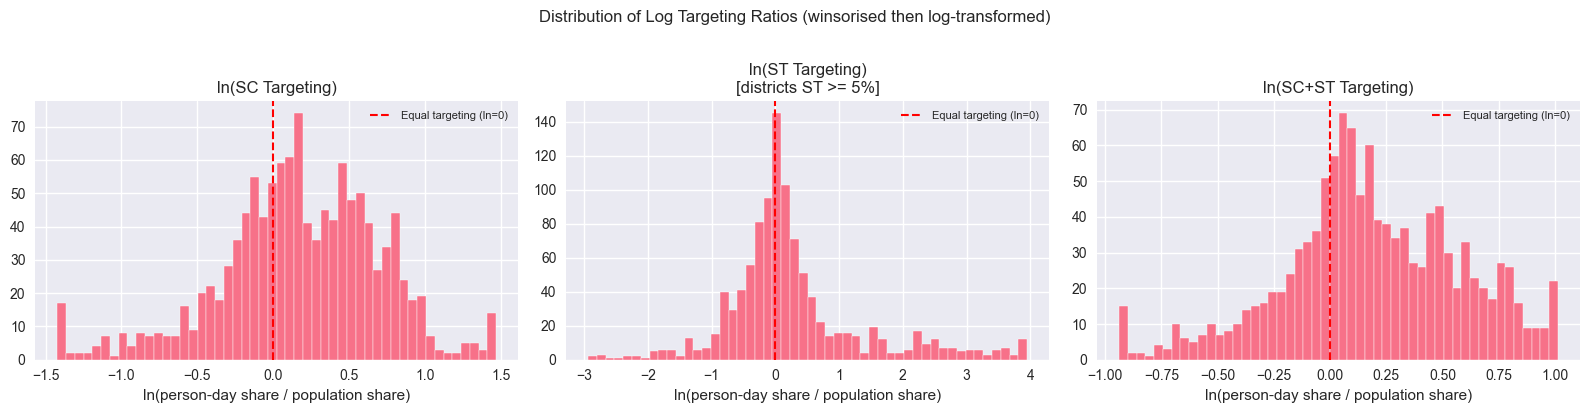

SC    — mean: +0.177, SD: 0.533, N: 1191
ST    — mean: +0.290, SD: 1.116, N: 1052
SC+ST — mean: +0.185, SD: 0.401, N: 1191

Within-district SD of fragmentation: 0.0000 (mean), 0.0000 (max)
-> Near zero confirms all identification is cross-sectional (cross-district).



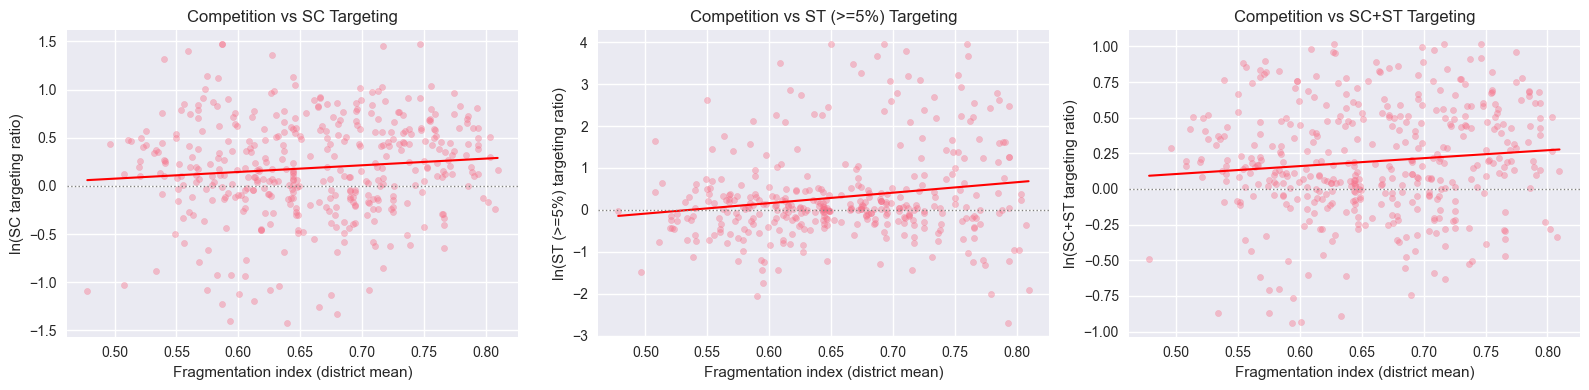

In [76]:
ST_POP_FLOOR = 0   # ST analysis restricted to districts where STs >= 5% of rural pop

panel['in_st_sample'] = panel['st_pop_share'] >= ST_POP_FLOOR

print(f"ST sample: {panel[panel['in_st_sample']]['district2011'].nunique()} / "
      f"{panel['district2011'].nunique()} districts have ST pop share >= {ST_POP_FLOOR:.0%}")
print(f"(dropped {panel['district2011'].nunique() - panel[panel['in_st_sample']]['district2011'].nunique()} "
      f"districts with near-zero ST population)\n")

# ── 1. Distributions of log-transformed outcomes ──────────────────────────────
sc_vals   = panel['ln_sc_targeting'].dropna()
st_vals   = panel.loc[panel['in_st_sample'], 'ln_st_targeting'].dropna()
scst_vals = panel['ln_scst_targeting'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, vals, title in zip(
    axes,
    [sc_vals, st_vals, scst_vals],
    ['ln(SC Targeting)', 'ln(ST Targeting)\n[districts ST >= 5%]', 'ln(SC+ST Targeting)'],
):
    ax.hist(vals, bins=50, edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Equal targeting (ln=0)')
    ax.set_title(title)
    ax.set_xlabel('ln(person-day share / population share)')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of Log Targeting Ratios (winsorised then log-transformed)', y=1.02)
plt.tight_layout()
plt.show()

print(f"SC    — mean: {sc_vals.mean():+.3f}, SD: {sc_vals.std():.3f}, N: {len(sc_vals)}")
print(f"ST    — mean: {st_vals.mean():+.3f}, SD: {st_vals.std():.3f}, N: {len(st_vals)}")
print(f"SC+ST — mean: {scst_vals.mean():+.3f}, SD: {scst_vals.std():.3f}, N: {len(scst_vals)}")

# ── 2. Within-district variation in competition variable ──────────────────────
within_var = panel.groupby('district2011')['fragmentation'].std()
print(f"\nWithin-district SD of fragmentation: "
      f"{within_var.mean():.4f} (mean), {within_var.max():.4f} (max)")
print("-> Near zero confirms all identification is cross-sectional (cross-district).\n")

# ── 3. Scatter: competition vs mean log-targeting ─────────────────────────────
mean_sc   = panel.groupby('district2011')[['fragmentation', 'ln_sc_targeting']].mean().dropna()
mean_st   = (panel[panel['in_st_sample']]
             .groupby('district2011')[['fragmentation', 'ln_st_targeting']].mean().dropna())
mean_scst = panel.groupby('district2011')[['fragmentation', 'ln_scst_targeting']].mean().dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, df, ycol, label in zip(
    axes,
    [mean_sc, mean_st, mean_scst],
    ['ln_sc_targeting', 'ln_st_targeting', 'ln_scst_targeting'],
    ['SC', 'ST (>=5%)', 'SC+ST'],
):
    ax.scatter(df['fragmentation'], df[ycol], alpha=0.4, s=20)
    m, b = np.polyfit(df['fragmentation'], df[ycol], 1)
    x_range = np.linspace(df['fragmentation'].min(), df['fragmentation'].max(), 100)
    ax.plot(x_range, m * x_range + b, color='red', linewidth=1.5)
    ax.axhline(0, color='grey', linestyle=':', linewidth=1)
    ax.set_xlabel('Fragmentation index (district mean)')
    ax.set_ylabel(f'ln({label} targeting ratio)')
    ax.set_title(f'Competition vs {label} Targeting')
plt.tight_layout()
plt.show()


## Step 8: Regression

**Main specification:**

$$\ln(\text{Targeting}_{dt}) = \alpha_s + \lambda_t + \beta \cdot \text{Competition}_d + \gamma' X_d + \delta' Z_{dt} + \varepsilon_{dt}$$

where:
- $\alpha_s$ = **state fixed effects** — absorb state-level confounders (governance capacity, MGNREGA implementation quality, baseline SC/ST welfare). Identification is cross-district *within* states.
- $\lambda_t$ = **year fixed effects** — absorb common year-on-year shocks
- $\text{Competition}_d$ = standardised fragmentation index from the 2004 election (constant within districts)
- $X_d$ = time-invariant district controls from Census 2011: urbanisation, share of children under 6, literacy, poverty rate, caste fractionalization, religion fractionalization, log population
- $Z_{dt}$ = time-varying district controls from NDAP: log total person-days, log households that demanded work, log amount sanctioned, log total works — these capture variation in programme scale and effort across districts and years

Standard errors are clustered at the district level.

**Robustness:** Re-run with **state × year fixed effects** (replacing separate state and year FEs) to absorb state-specific trends, using all three competition measures.


In [77]:
import statsmodels.formula.api as smf

DISTRICT_CONTROLS = (
    'urbanization + share_l6 + share_lit + poverty + '
    'caste_frac + religion_frac + ln_population'
)
TIME_CONTROLS = (
    'ln_total_pd + ln_hh_demanded + ln_amount_sanctioned + ln_total_works'
)
ALL_CONTROLS = f'{DISTRICT_CONTROLS} + {TIME_CONTROLS}'

results = {}

for outcome, label, st_floor in [
    ('ln_sc_targeting',   'SC',    False),
    ('ln_st_targeting',   'ST',    True),
    ('ln_scst_targeting', 'SC+ST', False),
]:
    base     = panel if not st_floor else panel[panel['in_st_sample']]
    reg_data = base.dropna(
        subset=[outcome, 'fragmentation_std', 'state', 'year']
    ).copy()

    formula = (
        f'{outcome} ~ fragmentation_std + {ALL_CONTROLS} + C(state) + C(year)'
    )
    m = smf.ols(formula, data=reg_data).fit(
        cov_type='cluster', cov_kwds={'groups': reg_data['district2011']}
    )
    results[label] = m

    sample_note = f'  [ST pop >= {ST_POP_FLOOR:.0%}]' if st_floor else ''
    print(f"\n{'='*65}")
    print(f"  {label} TARGETING  --  State FEs + Year FEs  "
          f"(N={int(m.nobs)}){sample_note}")
    print(f"{'='*65}")
    print(f"  {'Variable':<32} {'beta':>8}  {'SE':>8}  {'p':>6}")
    print(f"  {'-'*60}")

    key_vars = (
        ['fragmentation_std'] +
        DISTRICT_CONTROLS.split(' + ') +
        TIME_CONTROLS.split(' + ')
    )
    for var in key_vars:
        if var not in m.params:
            continue
        stars = ('***' if m.pvalues[var] < 0.01 else
                 '**'  if m.pvalues[var] < 0.05 else
                 '*'   if m.pvalues[var] < 0.10 else '')
        print(f"  {var:<32} {m.params[var]:>+8.4f}  "
              f"{m.bse[var]:>8.4f}  {m.pvalues[var]:>6.3f} {stars}")

    print(f"  {'R2':<32} {m.rsquared:>8.3f}")
    print(f"  {'R2 (adj)':<32} {m.rsquared_adj:>8.3f}")



  SC TARGETING  --  State FEs + Year FEs  (N=1191)
  Variable                             beta        SE       p
  ------------------------------------------------------------
  fragmentation_std                 -0.0522    0.0415   0.208 
  urbanization                      -0.4257    0.2589   0.100 
  share_l6                          +0.6181    2.4883   0.804 
  share_lit                         +0.2995    0.4599   0.515 
  poverty                           +0.7097    0.2113   0.001 ***
  caste_frac                        -0.1159    0.3140   0.712 
  religion_frac                     +0.0114    0.0639   0.859 
  ln_population                     -0.3558    0.2105   0.091 *
  ln_total_pd                       -0.0104    0.0385   0.787 
  ln_hh_demanded                    +0.0012    0.0039   0.750 
  ln_amount_sanctioned              -0.0114    0.0051   0.025 **
  ln_total_works                    -0.0421    0.0386   0.275 
  R2                                  0.388
  R2 (adj)       

## Step 8 (cont.): Interpreting the Regression Outputs

> **Note:** Fill in the bracketed placeholders `[X.XX]` after running the regression cell above.

---

### Main finding: effect of political competition on targeting equity

The key coefficient of interest is on `fragmentation_std` — a one-standard-deviation increase in the pre-delimitation fragmentation index (higher = more competitive). Results across outcomes:

| Outcome | β | SE | p-value | Interpretation |
|---|---|---|---|---|
| SC targeting | `[X.XX]` | `[X.XX]` | `[X.XX]` | |
| ST targeting (≥5% pop) | `[X.XX]` | `[X.XX]` | `[X.XX]` | |
| SC+ST targeting | `[X.XX]` | `[X.XX]` | `[X.XX]` | |

**How to read the coefficient:** The outcome is log-transformed, so the coefficient is an approximate percentage change. A coefficient of −0.05 means a one-SD increase in political competition is associated with a ~5% *decrease* in the targeting ratio relative to equal targeting (ratio = 1).

**Sign interpretation:**
- **Negative β** — more competitive districts target SCs/STs *less* proportionately. A political economy explanation: in close races, politicians spread benefits broadly to court swing voters rather than concentrating them on historically marginalised groups, reducing redistributive targeting.
- **Positive β** — more competitive districts target SCs/STs *more*. Consistent with a mobilisation story: electoral competition raises the returns to turning out core SC/ST constituencies, incentivising politicians to deliver more visible programme benefits to these groups.
- **Near-zero / insignificant β** — no detectable relationship in the 2011–2013 window, suggesting that variation in pre-delimitation competition across districts within the same state does not translate into differential targeting equity once programme scale and district demographics are held constant.

---

### Controls

**Time-invariant district controls** (Census 2011): urbanisation, share of children under 6, literacy rate, poverty rate, caste fractionalization, religion fractionalization, and log rural population. These absorb the cross-district variation in economic and social structure that independently predicts both political competition and how well programmes reach marginalised groups.

**Time-varying programme controls** (NDAP): log total person-days (`ln_total_pd`), log households that demanded work (`ln_hh_demanded`), log amount sanctioned, and log total works. These capture the scale and administrative effort of MGNREGA delivery in each district-year, preventing the competition coefficient from picking up the mechanical relationship between programme size and proportionate coverage.

---

### Identification caveat

State fixed effects absorb all state-level confounders, so the comparison is **within-state across districts**. Because `fragmentation_2004_past` is derived from a single election and does not change within a district across the three sample years, the identifying variation is effectively **cross-sectional** — comparing more versus less competitive districts within the same state. Year fixed effects absorb aggregate time trends. This is an observational comparison, not a quasi-experiment; coefficients should be interpreted as conditional correlations rather than causal effects. The robustness tables below check whether results hold when state-specific trends are absorbed by state × year fixed effects.


In [78]:
# ── Robustness Table A: alternative competition measures, State FEs ──────────
print(f"Robustness A -- State + Year FEs, alternative competition measures")
print(f"(ST restricted to districts with ST pop share >= {ST_POP_FLOOR:.0%})\n")
print(f"{'Measure':<25} {'SC b':>8} {'SC p':>6} {'ST b':>8} {'ST p':>6} {'SC+ST b':>9} {'SC+ST p':>8}")
print("-" * 75)

SAMPLES = [
    ('ln_sc_targeting',   panel),
    ('ln_st_targeting',   panel[panel['in_st_sample']]),
    ('ln_scst_targeting', panel),
]

for comp_var, comp_label in [
    ('fragmentation_std', 'Fragmentation'),
    ('min_margin_std',    'Min margin'),
    ('eff_parties_std',   'Eff. parties'),
]:
    row = [comp_label]
    for outcome, base in SAMPLES:
        fit_data = base.dropna(subset=[outcome, comp_var])
        m = smf.ols(
            f'{outcome} ~ {comp_var} + {ALL_CONTROLS} + C(state) + C(year)',
            data=fit_data
        ).fit(cov_type='cluster', cov_kwds={'groups': fit_data['district2011']})
        row += [m.params[comp_var], m.pvalues[comp_var]]
    print(f"{row[0]:<25} {row[1]:>+8.4f} {row[2]:>6.3f} {row[3]:>+8.4f} {row[4]:>6.3f} {row[5]:>+9.4f} {row[6]:>8.3f}")

# ── Robustness Table B: State x Year FEs ─────────────────────────────────────
print(f"\nRobustness B -- State x Year FEs, alternative competition measures\n")
print(f"{'Measure':<25} {'SC b':>8} {'SC p':>6} {'ST b':>8} {'ST p':>6} {'SC+ST b':>9} {'SC+ST p':>8}")
print("-" * 75)

for comp_var, comp_label in [
    ('fragmentation_std', 'Fragmentation'),
    ('min_margin_std',    'Min margin'),
    ('eff_parties_std',   'Eff. parties'),
]:
    row = [comp_label]
    for outcome, base in SAMPLES:
        fit_data = base.dropna(subset=[outcome, comp_var]).copy()
        fit_data['state_year'] = (fit_data['state'].astype(str) + '_' +
                                  fit_data['year'].astype(str))
        m = smf.ols(
            f'{outcome} ~ {comp_var} + {ALL_CONTROLS} + C(state_year)',
            data=fit_data
        ).fit(cov_type='cluster', cov_kwds={'groups': fit_data['district2011']})
        row += [m.params[comp_var], m.pvalues[comp_var]]
    print(f"{row[0]:<25} {row[1]:>+8.4f} {row[2]:>6.3f} {row[3]:>+8.4f} {row[4]:>6.3f} {row[5]:>+9.4f} {row[6]:>8.3f}")


Robustness A -- State + Year FEs, alternative competition measures
(ST restricted to districts with ST pop share >= 0%)

Measure                       SC b   SC p     ST b   ST p   SC+ST b  SC+ST p
---------------------------------------------------------------------------
Fragmentation              -0.0522  0.208  -0.2317  0.009   -0.0132    0.558
Min margin                 +0.0084  0.794  -0.1688  0.046   -0.0036    0.843
Eff. parties               -0.0439  0.232  -0.3772  0.000   -0.0188    0.397

Robustness B -- State x Year FEs, alternative competition measures

Measure                       SC b   SC p     ST b   ST p   SC+ST b  SC+ST p
---------------------------------------------------------------------------
Fragmentation              -0.0579  0.162  -0.2264  0.012   -0.0148    0.513
Min margin                 +0.0114  0.724  -0.1704  0.045   -0.0026    0.889
Eff. parties               -0.0501  0.175  -0.3730  0.000   -0.0205    0.358
